<a href="https://colab.research.google.com/github/italemp/Python-for-biology-and-chemistry/blob/main/Project_Itzel_Muro_object%20oriented.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classifying molecules from PubChem for chemical inventory

In a chemical laboratory, determining whether a compound is water reactive, water non-reactive, nucleophilic, electrophilic, among other things is quite difficult at a first glance at a bottle or container. Being able to classify compounds easily based on the information on the label (such as a CAS number) is relevant to how the chemical inventory is stored as to avoid cross-reactivity between reactants, especially if done by non-chemistry background people. This project will set the foundation for this. It is based on the white paper *Practical Segregation of Incompatible Reagents In The Organic Chemistry Laboratory*, written by John Wiener and Cheryl Grice (2009). They developed a 7-group classification as seen in the following table:

| Abbreviation | Group |
| ----------- | ----------- |
| OX | Oxidizer |
| NEUT | Neutral |
| WNR NUC | Water-nonreactive Nucleophilic |
| WR NUC | Water-reactive Nucleophilic |
| WNR ELEC | Water-nonreactive Electrophilic |
| WR ORG ELEC | Water-reactive Organic Electrophilic |
| WR INORG ELEC | Water-reactive Inorganic Electrophilic |

Functional groups present in the molecule are obtained through the utility program [checkmol](https://homepage.univie.ac.at/norbert.haider/cheminf/cmmm.html). First, checkmol is downloaded and compiled:

In [ ]:
#Download the file "checkmol.pas".
!wget https://homepage.univie.ac.at/norbert.haider/download/chemistry/checkmol/checkmol.pas

#Install free pascal compiler.
!apt install -y fp-compiler

#Compile checkmol according to checkmol's website instructions: https://homepage.univie.ac.at/norbert.haider/cheminf/cmmm.html#compile.
!fpc checkmol.pas -S2 -O3 -Op3

print("Finished downloading and compiling checkmol.")

--2025-05-26 16:13:44--  https://homepage.univie.ac.at/norbert.haider/download/chemistry/checkmol/checkmol.pas
Resolving homepage.univie.ac.at (homepage.univie.ac.at)... 131.130.70.29, 2001:62a:4:70::80:132
Connecting to homepage.univie.ac.at (homepage.univie.ac.at)|131.130.70.29|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 555927 (543K)
Saving to: ‘checkmol.pas.1’

checkmol.pas.1      100%[===================>] 542.90K   418KB/s    in 1.3s    

2025-05-26 16:13:47 (418 KB/s) - ‘checkmol.pas.1’ saved [555927/555927]

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fp-compiler is already the newest version (3.2.2+dfsg-9ubuntu1).
0 upgraded, 0 newly installed, 0 to remove and 34 not upgraded.
Free Pascal Compiler version 3.2.2+dfsg-9ubuntu1 [2022/04/11] for x86_64
Copyright (c) 1993-2021 by Florian Klaempfl and others
Target OS: Linux for x86-64
Compiling checkmol.pas
Linking checkmol
14390 lines compiled, 0.8 

### Creation of a dictionary with the functional groups
Checkmol recognizes the 204 functional groups (listed in their [website](chrome-extension://efaidnbmnnnibpcajpcglclefindmkaj/https://homepage.univie.ac.at/norbert.haider/cheminf/fgtable.pdf)). Each one will be assigned a code in a .csv file according to the following table:

| Variable | Group |
| ----------- | ----------- |
| o | Oxidizer |
| n | Neutral |
| wnn | Water-nonreactive Nucleophilic |
| wrn | Water-reactive Nucleophilic |
| wne | Water-nonreactive Electrophilic |
| wroe | Water-reactive Organic Electrophilic |
| wrie | Water-reactive Inorganic Electrophilic |

Each group will be assigned a broarder group (i.e. cation, carbonyl, ketone, alcohol, etc.) for plotting a histogram of the functional groups present in the molecule. If left as is, the histogram would most likely have one of each group; thus, this simple reduction is made to have more variety in it. Consequently, two dictionaries will be created.

In [ ]:
#Download dictionary files.
!wget https://raw.githubusercontent.com/italemp/Python-for-biology-and-chemistry/refs/heads/main/project%20files/class1.csv
!wget https://raw.githubusercontent.com/italemp/Python-for-biology-and-chemistry/refs/heads/main/project%20files/class2.csv

import pandas as pd

#Making a dictionary for the classification.
class_dict = {row.iloc[0] : row.iloc[1] for _, row in pd.read_csv("class1.csv").iterrows()}

#Making a dictionary for the histogram.
hist_dict = {row.iloc[0] : row.iloc[1] for _, row in pd.read_csv("class2.csv").iterrows()}

--2025-05-26 16:14:29--  https://raw.githubusercontent.com/italemp/Python-for-biology-and-chemistry/refs/heads/main/project%20files/class1.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5365 (5.2K) [text/plain]
Saving to: ‘class1.csv.5’

class1.csv.5        100%[===================>]   5.24K  --.-KB/s    in 0s      

2025-05-26 16:14:29 (62.7 MB/s) - ‘class1.csv.5’ saved [5365/5365]

--2025-05-26 16:14:29--  https://raw.githubusercontent.com/italemp/Python-for-biology-and-chemistry/refs/heads/main/project%20files/class2.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP req

###The checkmol function
In order to define a function that stores the output of the checkmol output, two other functions must be defined first, one that downloads a .mol file (checkmol's input) from PubChem and one that retrieves the cid from the name of the compound (needed to download the .mol file).

In [ ]:
#Write a function to look for cid number of a compound directly from PubChem.
import requests

def get_cid(compound_name):
    '''Gets the cid from PubChem.'''

    url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/{compound_name}/cids/TXT"
    r = requests.get(url)
    if r.status_code == 200 and r.text.strip():
        cid = r.text.strip()
        #print(cid)
        return(cid)
    else:
        print(f"Did not find '{compound_name}' in PubChem. Check the spelling.")
        return None

#Write a function to download for .mol files directly from PubChem.
def get_mol(compound_name):
    '''Gets the .mol file from PubChem.'''

    cid = get_cid(compound_name)
    if cid is None:
        return None

    url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{cid}/record/SDF/?record_type=3d"
    r = requests.get(url)
    if r.status_code == 200:
        with open(compound_name, 'w') as f:
            f.write(r.text)
        #print(f"Succesfully downloaded {compound_name}.mol from PubChem.")
    else:
        print(f"Error downloadid the MOL file for '{compound_name}'.")

#Write a function to run checkmol.
def run_checkmol(compound_name):
    '''Runs checkmol on a .mol file.'''

    #Subprocess library must be imported.
    import subprocess as sp

    #Download the .mol file of the checkmol.
    get_mol(compound_name)

    #Checkmol gives the output as a byte object, but strings are easier to handle, so bytes are converted to a:
    try:
      out_byte=sp.check_output(["./checkmol",f"{compound_name}"])
      out_string=(out_byte.decode())
    except:
      print("Could not download .mol file from Pubchem. Check the spelling")
      return None

    #Separating the string.
    functional_groups=out_string.splitlines()

    #We get a list with the functional groups of the molecule:
    return functional_groups

#Make sur run_checkmol() function works with an example, i.e. aspirin should print out
#['carboxylic acid', 'carboxylic acid ester', 'aromatic compound'], but ultimately take a pick of the compound of your choice.
run_checkmol("aspirin")

['carboxylic acid', 'carboxylic acid ester', 'aromatic compound']

### Applying a hierarchy to functional groups to obtain the final classification
As mentioned in the article, some groups have higher hierarchy over others if present within the same molecule. From the article, that hierarchy is:
<center>OX > WR ORG ELEC > WR INORG ELEC > WR NUC > WNR ELEC = WNR NUC > NEUT = WNR ELEC + WNR NUC</center>

If a molecule has at least one WNR ELEC and WNR NUC group, it is considered the equivalent to NEUT (as seen in the last part of the hierarchy).

In [ ]:
#Translate the output of checkmol to a previously created dictionary.
def checkmol_to_dict(compound_name, dict_name):
  '''Translates the functional groups of the chosen molecule
  to the classifications from the chosen dictionary'''

  #Get the output from checkmol
  functional_groups = run_checkmol(compound_name)

  #Iterate through the functional groups list
  translated_list = []
  try:
    for x in functional_groups:
      for y in dict_name:
        if x==y:
          translated_list.append(dict_name[y])
  except:
    print("Could not translate the checkmol output, are you sure the molecule exists?")

  #Pretty things up
  translated_list.sort()
  return translated_list

#Hierarchy function.
def hierarchy(compound_name):
  '''Applies the hierarchy o > wroe > wrie > wrn > wne = wnn > n = wne + wnn.'''

  #Get the translated output from checkmol according to the classification dictionary.
  class_list = checkmol_to_dict(compound_name, class_dict)

  for item in class_list:
    if item=="o":
        classification="an oxidizer"
        break
    else:
        if item=="wroe":
            classification="water-reactive organic electrophilic"
            break
        else:
            if item=="wrie":
                classification="water-reactive inorganic electrophilic"
                break
            else:
                if item=="wrn":
                    classification="water-reactive nucleophilic"
                    break
                else:
                    if ("wne" in class_list)==True:
                        if ("wnn" in class_list)==True:
                            classification="neutral"
                            break
                        else:
                            classification="water-nonreactive electrophilic"
                            break
                    else:
                        if ("wnn" in class_list)==True:
                            classification="water-nonreactive nucleophilic"
                            break
                        else:
                            classification="neutral"
                            break
  print(f"The molecule is '{classification}'.")

#Classify a molecule, i.e. "aspirin" is classified as 'water-nonreactive electrophilic'.
hierarchy("aspirin")

The molecule is 'water-nonreactive electrophilic'.


### Classifying into broader groups for the plot

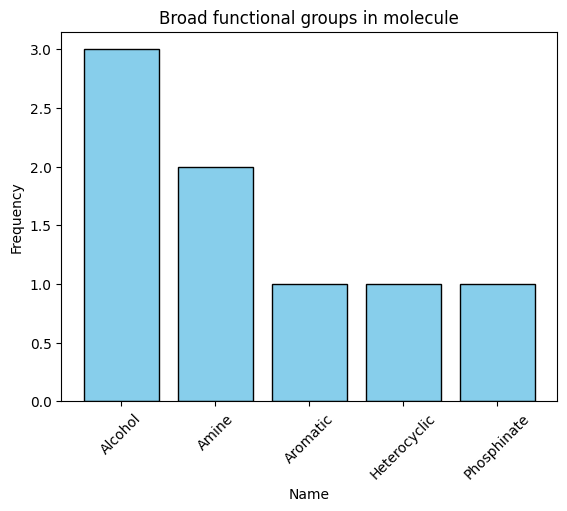

In [ ]:
#Histogram function
def histogram(compound_name):
  '''Obtain the categories to plot in the histogram and plot the histogram'''

  #Use of the checkmol_to_dict function to get the histogram classifications
  hist_list = checkmol_to_dict(compound_name,hist_dict)

  #Count the classifications.
  #Some classifications have more than one functional group, thus, the list can have multiple
  #functional groups per element, separated by a "," (up to two commas). Therefore we cannot use
  #directly a simple solution like "Counter()" from collections. In order to separate them:

  #Non-possible elegant solution:
  #from collections import Counter
  #count = Counter(hist_list)

  c=0
  while c < len(hist_list):
      item = str(hist_list[c])
      if ("," in item)==True:
          split_item=list(item.partition(", "))
          split_item.remove(", ")
          hist_list.remove(item)
          updated_hist_list=hist_list+split_item
          hist_list=updated_hist_list
      c=c+1

  #Make things pretty.
  try:
    updated_hist_list.sort()
    from collections import Counter
    count = Counter(updated_hist_list)

  #Plot the histogram.
    import matplotlib.pyplot as plt
    plt.bar(count.keys(), count.values(), color="skyblue", edgecolor="black")
    plt.title('Broad functional groups in molecule')
    plt.xlabel('Name')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)
    plt.show()
  except:
    print("Could not plot the histogram :(")

#Plot the histogram for a molecule, pick an interesting one!
histogram("ATP")


### References
- Haider, N. (2022). Checkmol/Matchmol Homepage. Retrieved 26 May 2025, from https://homepage.univie.ac.at/norbert.haider/cheminf/cmmm.html
- Wiener, J., & Grice, C. (2009). Practical Segregation of Incompatible Reagents in the Organic Chemistry Laboratory. *Organic Process Research &Amp; Development, 13*(6), 1395-1400. doi: 10.1021/op900094d